In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,CIFAR100


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.ToTensor()
])          


In [3]:
cifar100_train = CIFAR100(root='./data', train=True, download=True, transform=transform)
cifar100_test = CIFAR100(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar100_train)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size -valid_size)

trainset,validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

40000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=3.0414683969497682,train_accu=0.2121
Epoch=0,valid_loss=3.088306271362305,valid_accu=0.2078
0
Epoch=1,train_loss=2.6219280477523803,train_accu=0.303825
Epoch=1,valid_loss=2.6924914218902587,valid_accu=0.2885
0
Epoch=2,train_loss=2.529245453262329,train_accu=0.331225
Epoch=2,valid_loss=2.6127424297332764,valid_accu=0.3149
0
Epoch=3,train_loss=2.4771931467056274,train_accu=0.3427
Epoch=3,valid_loss=2.568497787475586,valid_accu=0.3252
0
Epoch=4,train_loss=2.394717223739624,train_accu=0.362675
Epoch=4,valid_loss=2.4966582790374754,valid_accu=0.3457
0
Epoch=5,train_loss=2.2772686663627626,train_accu=0.382225
Epoch=5,valid_loss=2.3835326736450195,valid_accu=0.36
0
Epoch=6,train_loss=2.2825083733558653,train_accu=0.386975
Epoch=6,valid_loss=2.3944654132843017,valid_accu=0.3643
0
Epoch=7,train_loss=2.1990704785346984,train_accu=0.406175
Epoch=7,valid_loss=2.320495434188843,valid_accu=0.3816
0
Epoch=8,train_loss=2.1708589506149294,train_accu=0.414975
Epoch=8,valid_loss=2.2952

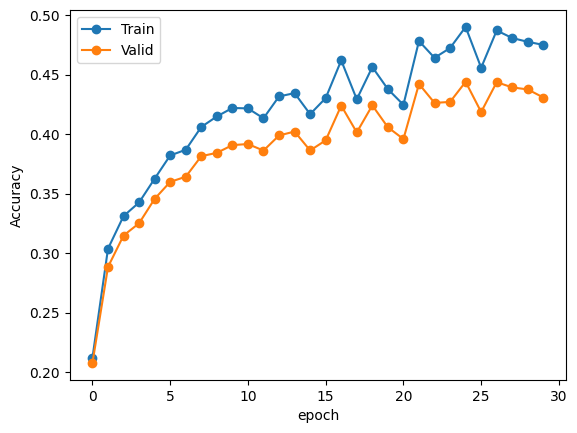

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_8.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(1.8661049723625183, 0.49025)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(2.039518141746521, 0.4441)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu=each_accu.sort_values(ascending=True)
each_accu

otter        0.038363
girl         0.082324
squirrel     0.106599
rabbit       0.107232
seal         0.131646
               ...   
plain        0.827338
chair        0.832080
road         0.841076
orange       0.868159
sunflower    0.869018
Length: 100, dtype: float64

In [15]:
each_f1=2*p*r/(p+r)
each_f1

apple            0.755127
aquarium_fish    0.540000
baby             0.368280
bear             0.249307
beaver           0.259470
                   ...   
whale            0.540179
willow_tree      0.484006
wolf             0.419355
woman            0.344633
worm             0.505181
Length: 100, dtype: float64

In [16]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',40)

if(split_mode[0]=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
elif(split_mode[0]=='classaccu'):
    targetF=[x  for x in each_accu.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
else:
    split=split_mode

indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(15956, 24044)

In [17]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(4044, 5956)

In [18]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [20]:
# class_counts = [0, 0]
# for _,_,label,_ in trainset:
#     class_counts[label] +=1

In [21]:
# # 计算每个类别的权重
# class_weights = [1.0 / count for count in class_counts]
# weights = torch.FloatTensor(class_weights).cuda()

In [24]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)

    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    elif(data_name=='0'):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay=1e-2)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    else:   

        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model

Epoch=0,train_loss=0.5444376541137695,train_accu=0.715625
Epoch=0,valid_loss=0.5530711904048919,valid_accu=0.7109
0
Epoch=1,train_loss=0.5254294602394104,train_accu=0.731725
Epoch=1,valid_loss=0.5396140145301819,valid_accu=0.7251
0
Epoch=2,train_loss=0.5085272030830383,train_accu=0.7433
Epoch=2,valid_loss=0.5254728252410888,valid_accu=0.7315
0
Epoch=3,train_loss=0.4963375926733017,train_accu=0.75415
Epoch=3,valid_loss=0.5204994647026062,valid_accu=0.7399
0
Epoch=4,train_loss=0.4832783776283264,train_accu=0.75765
Epoch=4,valid_loss=0.5095171099662781,valid_accu=0.739
Epoch=5,train_loss=0.47404585095644,train_accu=0.764875
Epoch=5,valid_loss=0.5034379292011261,valid_accu=0.7441
0
Epoch=6,train_loss=0.4597300921201706,train_accu=0.773525
Epoch=6,valid_loss=0.4941584579467773,valid_accu=0.7534
0
Epoch=7,train_loss=0.4536111990213394,train_accu=0.778675
Epoch=7,valid_loss=0.49105871353149416,valid_accu=0.7521
Epoch=8,train_loss=0.45014141805171964,train_accu=0.783175
Epoch=8,valid_loss=0.48

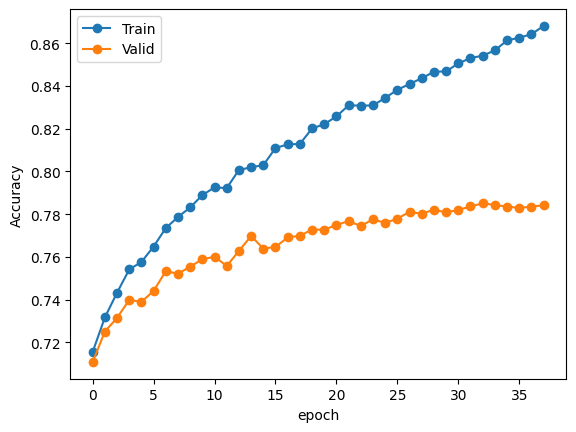

In [25]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",70,model_0=model_0)

In [26]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=1.1469344436338986,train_accu=0.6537181833305606
Epoch=0,valid_loss=1.3294330408622788,valid_accu=0.6114842175957018
0
Epoch=1,train_loss=1.0333739392988655,train_accu=0.6886125436699384
Epoch=1,valid_loss=1.2391895202280612,valid_accu=0.6343183344526527
0
Epoch=2,train_loss=0.975257790637996,train_accu=0.7062884711362503
Epoch=2,valid_loss=1.2139459380853728,valid_accu=0.6400268636668905
0
Epoch=3,train_loss=0.9160175264288236,train_accu=0.7265430044917651
Epoch=3,valid_loss=1.1677799269687097,valid_accu=0.6549697783747481
0
Epoch=4,train_loss=0.8704048165107324,train_accu=0.7405173847945433
Epoch=4,valid_loss=1.142793196131512,valid_accu=0.6600067159167227
0
Epoch=5,train_loss=0.8431235022819333,train_accu=0.7426800865080685
Epoch=5,valid_loss=1.1391944036618264,valid_accu=0.6682337139019476
0
Epoch=6,train_loss=0.7926337367939763,train_accu=0.7643486940608883
Epoch=6,valid_loss=1.099025058618242,valid_accu=0.6732706514439221
0
Epoch=7,train_loss=0.7876915587916428

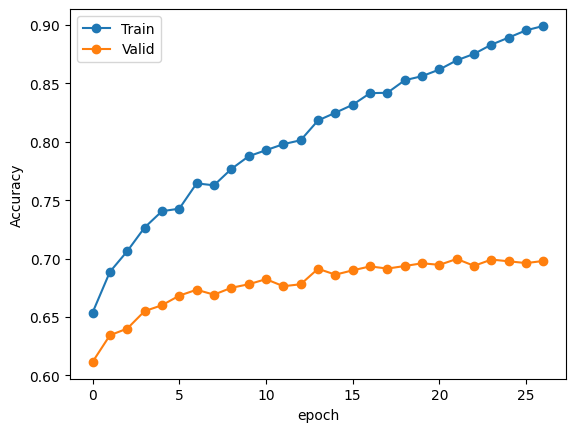

In [27]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.7302872739539883,train_accu=0.47468037102030586
Epoch=0,valid_loss=1.8843429142832167,valid_accu=0.42729970326409494
0
Epoch=1,train_loss=1.5858549095090693,train_accu=0.5171722236149411
Epoch=1,valid_loss=1.794361196333058,valid_accu=0.4638971315529179
0
Epoch=2,train_loss=1.5264407803642328,train_accu=0.5424918525946353
Epoch=2,valid_loss=1.7579934731435352,valid_accu=0.4752720079129575
0
Epoch=3,train_loss=1.4783130936468416,train_accu=0.5551516670844824
Epoch=3,valid_loss=1.7325161976111514,valid_accu=0.47403560830860536
Epoch=4,train_loss=1.4178837842288607,train_accu=0.5753321634494861
Epoch=4,valid_loss=1.7016653343666672,valid_accu=0.49258160237388726
0
Epoch=5,train_loss=1.391662323196958,train_accu=0.5839182752569566
Epoch=5,valid_loss=1.6980887087822905,valid_accu=0.5002472799208705
0
Epoch=6,train_loss=1.3419077811189748,train_accu=0.5925043870644272
Epoch=6,valid_loss=1.6705944409592097,valid_accu=0.4992581602373887
Epoch=7,train_loss=1.289850917457787

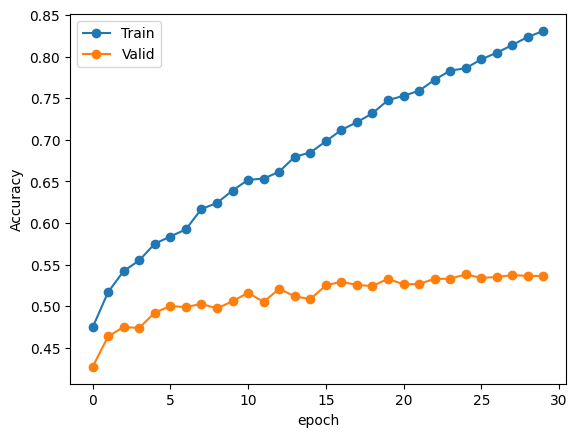

In [28]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [29]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.34270104706287385, 0.854125)

In [30]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.44901295247077944, 0.7851)

In [31]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.45086656212608384, 0.8696972217601064)

In [32]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.7813792087942713, 0.7860366006517925)

In [33]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(1.040704901063098, 0.6996306245802552)

In [34]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.5796246407175867, 0.5385756676557863)

In [35]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.5827079770922661, 0.836325, 15956)

In [36]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.2586445348739623, 0.6344, 4044)

In [37]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(4.441320311260223, 0.719625, 16307, 23693)

In [38]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(6.709278924560547, 0.5215, 4067, 5933)

In [39]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [40]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classaccu', [55, 35, 80, 65, 72, 93, 11, 44, 25, 3, 32, 50, 78, 92, 26, 70, 98, 30, 90, 67, 64, 29, 4, 13, 42, 40, 15, 2, 10, 59, 45, 34, 83, 66, 22, 86, 14, 63, 18, 38])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,1.866105,0.490250,2.039518,0.444100
1,Model_Decision,0.342701,0.854125,0.449013,0.785100
2,Model_T,0.450867,0.869697,1.040705,0.699631
3,Model_F,0.781379,0.786037,1.579625,0.538576
4,Total_Model,4.441320,0.719625,6.709279,0.521500
5,Total_Model_with_perfect_decision,0.582708,0.836325,1.258645,0.634400


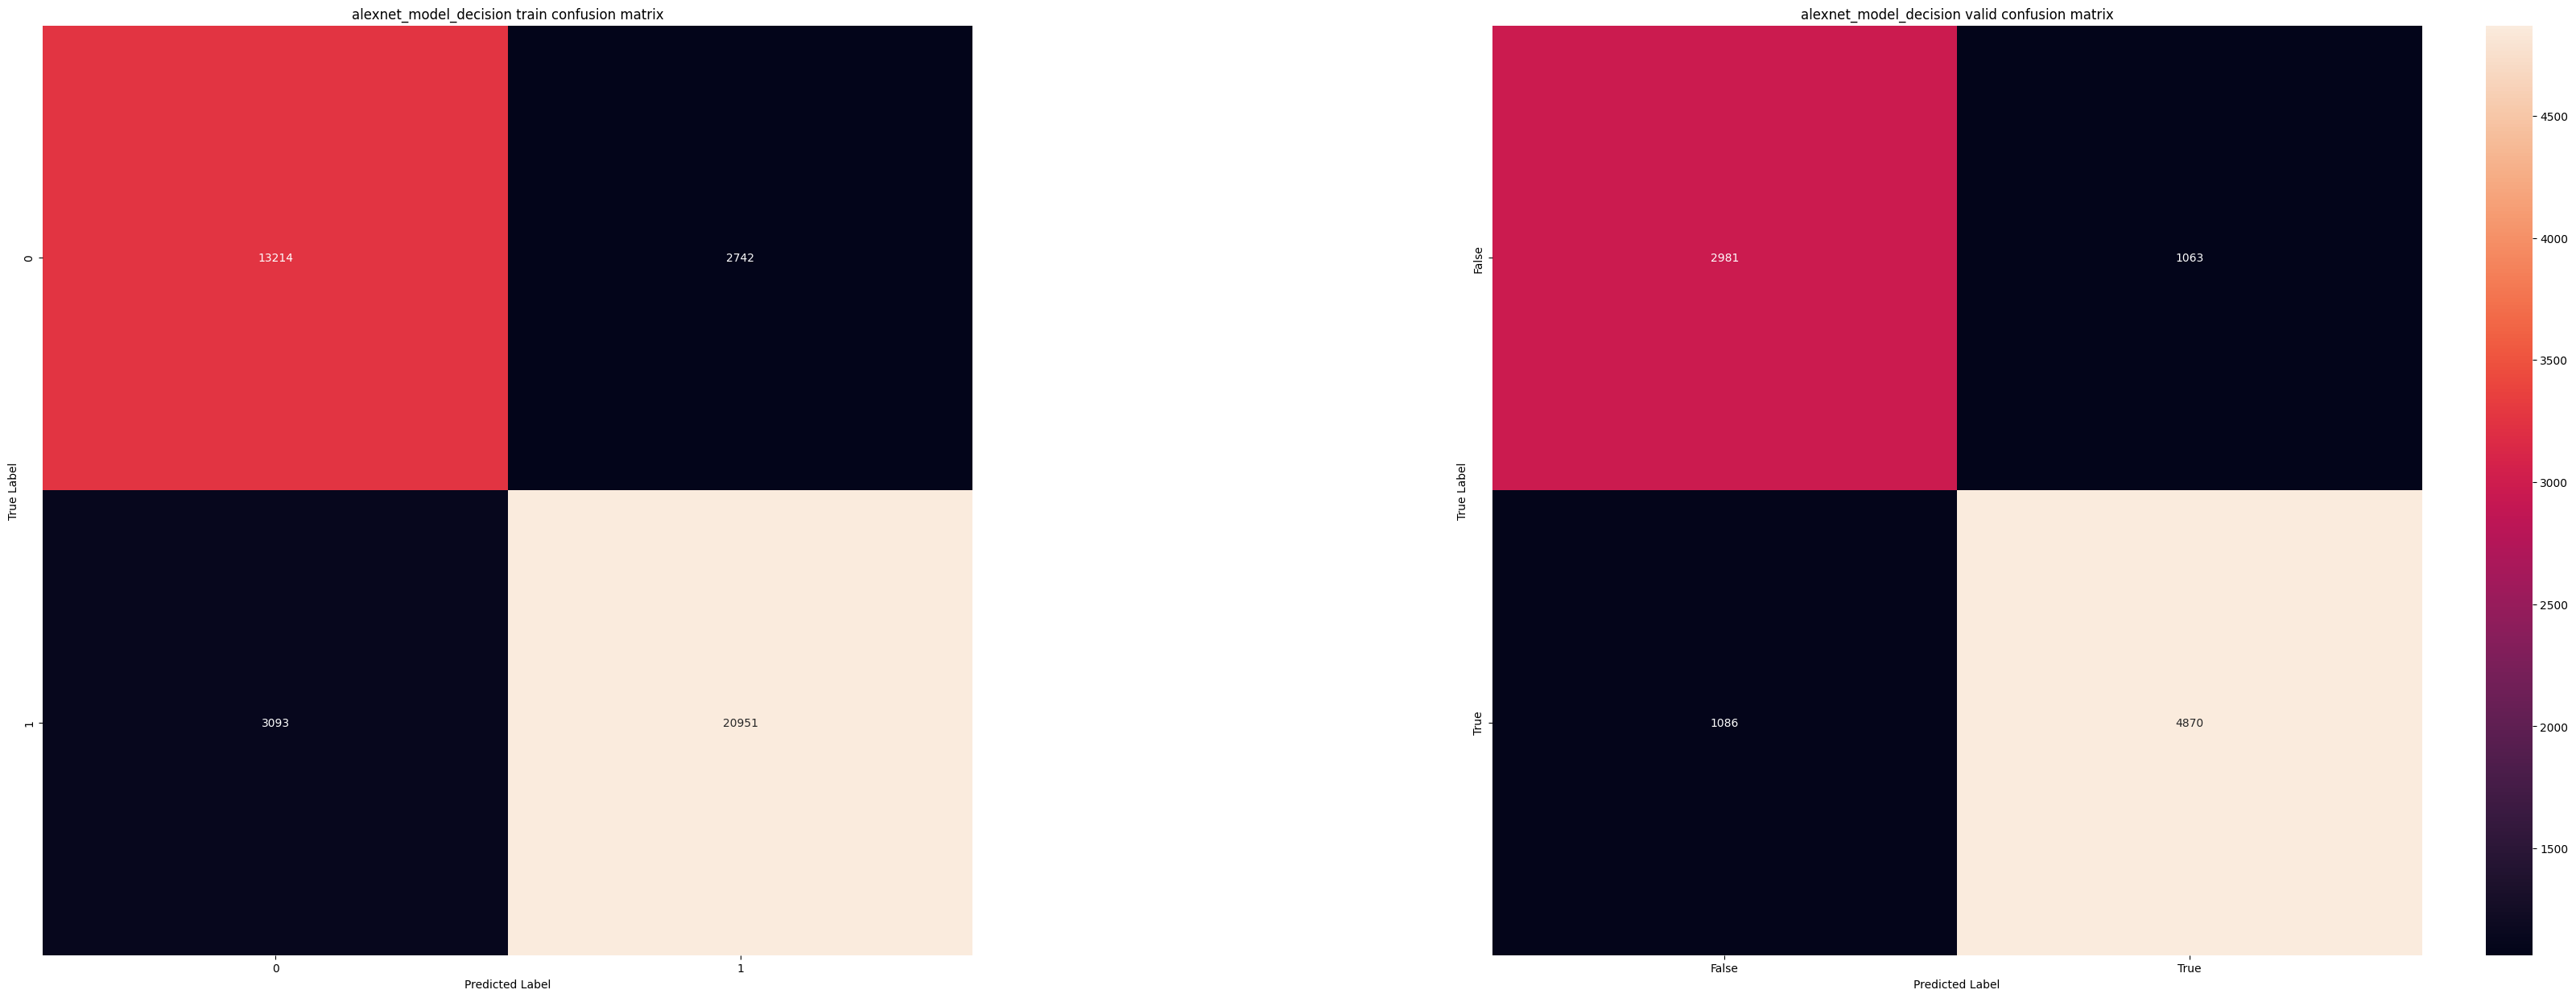

In [41]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

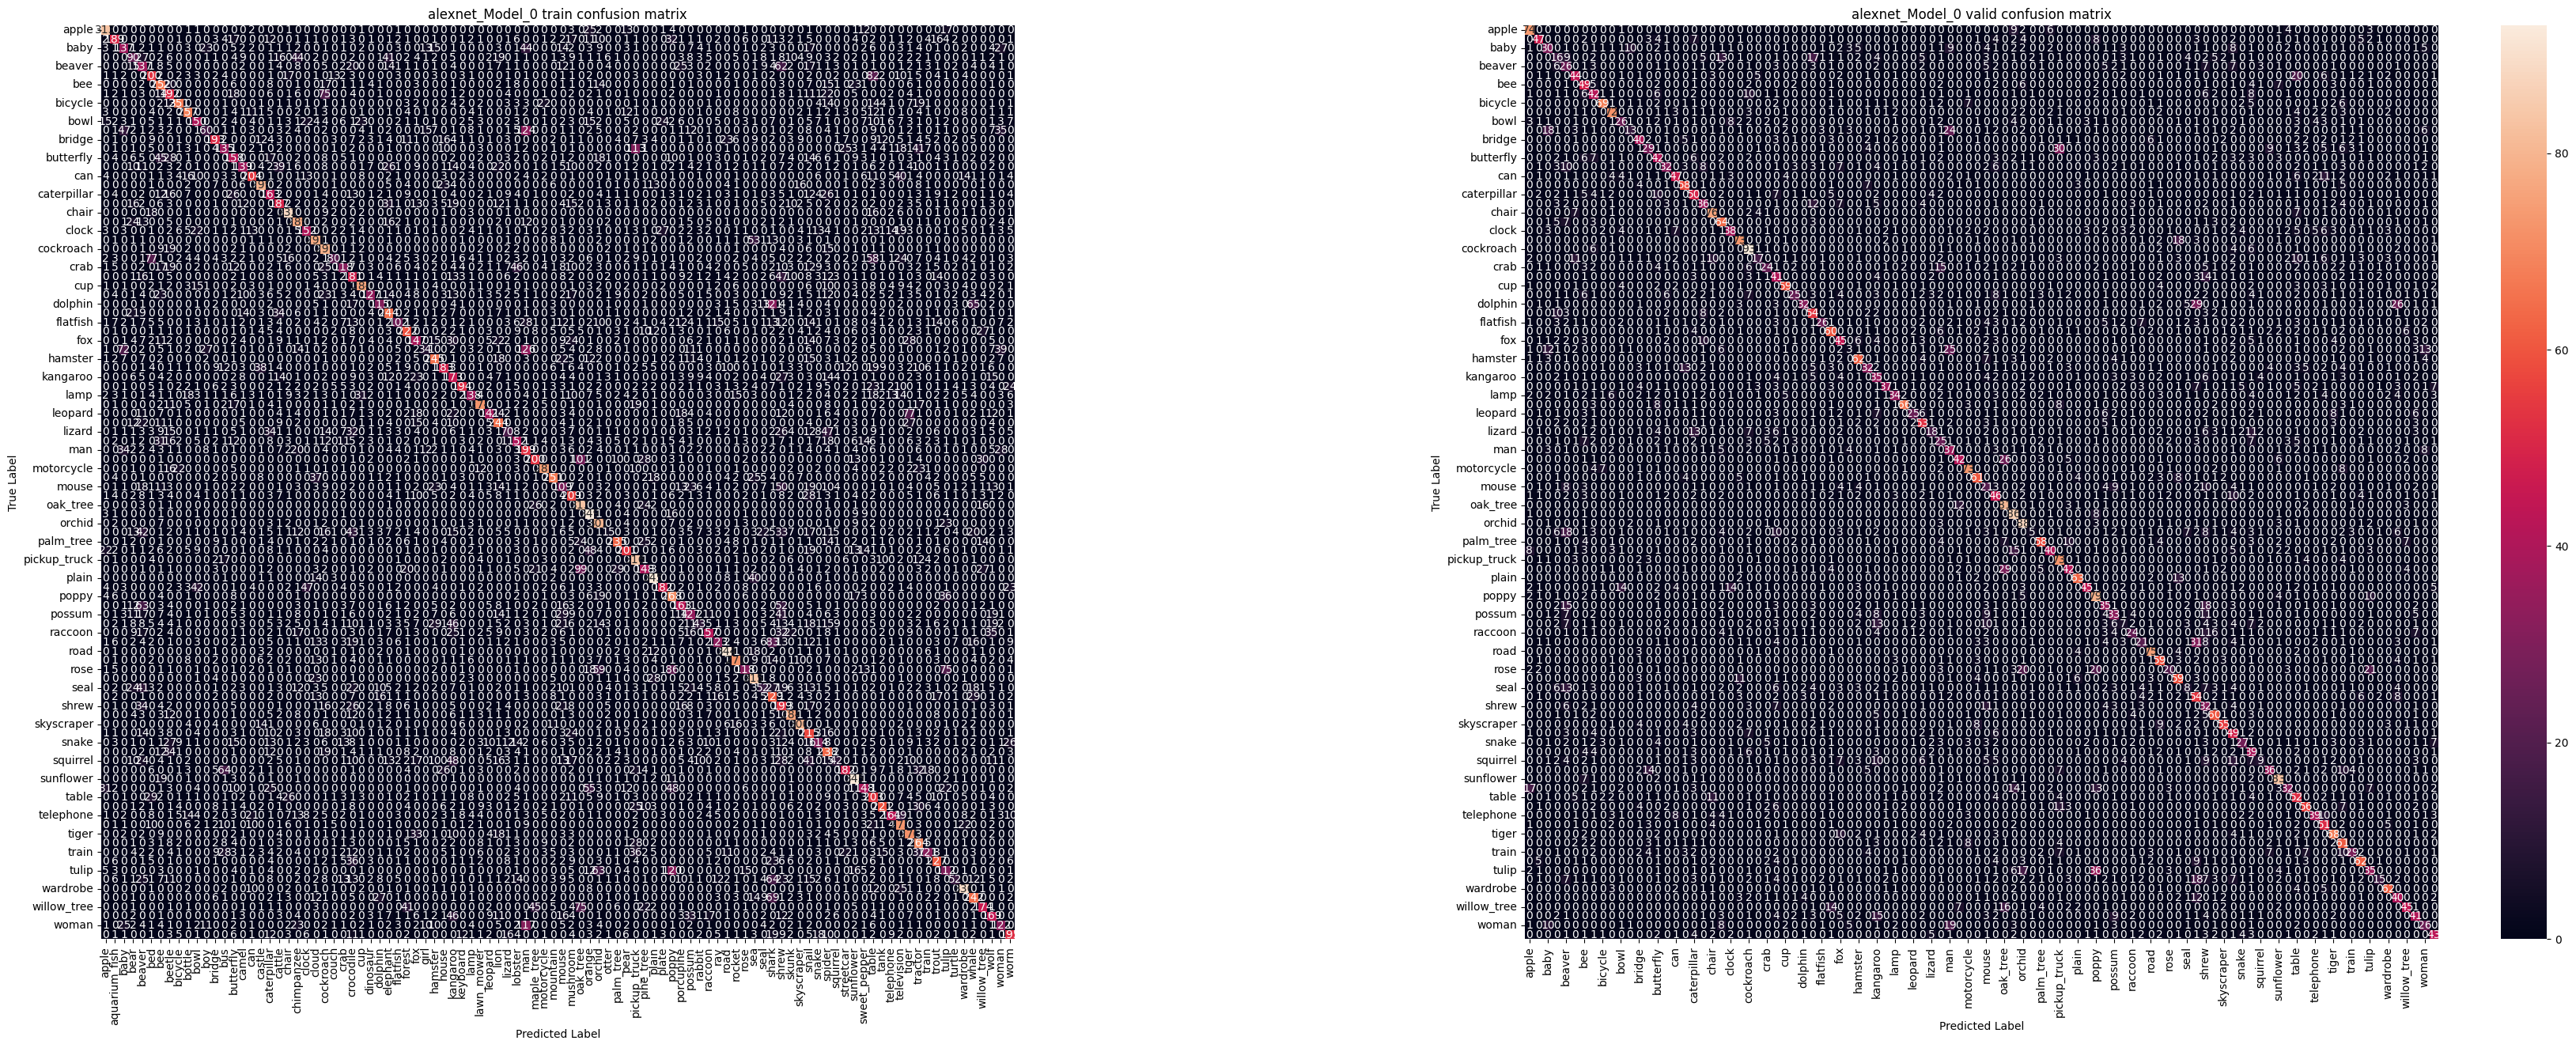

In [42]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

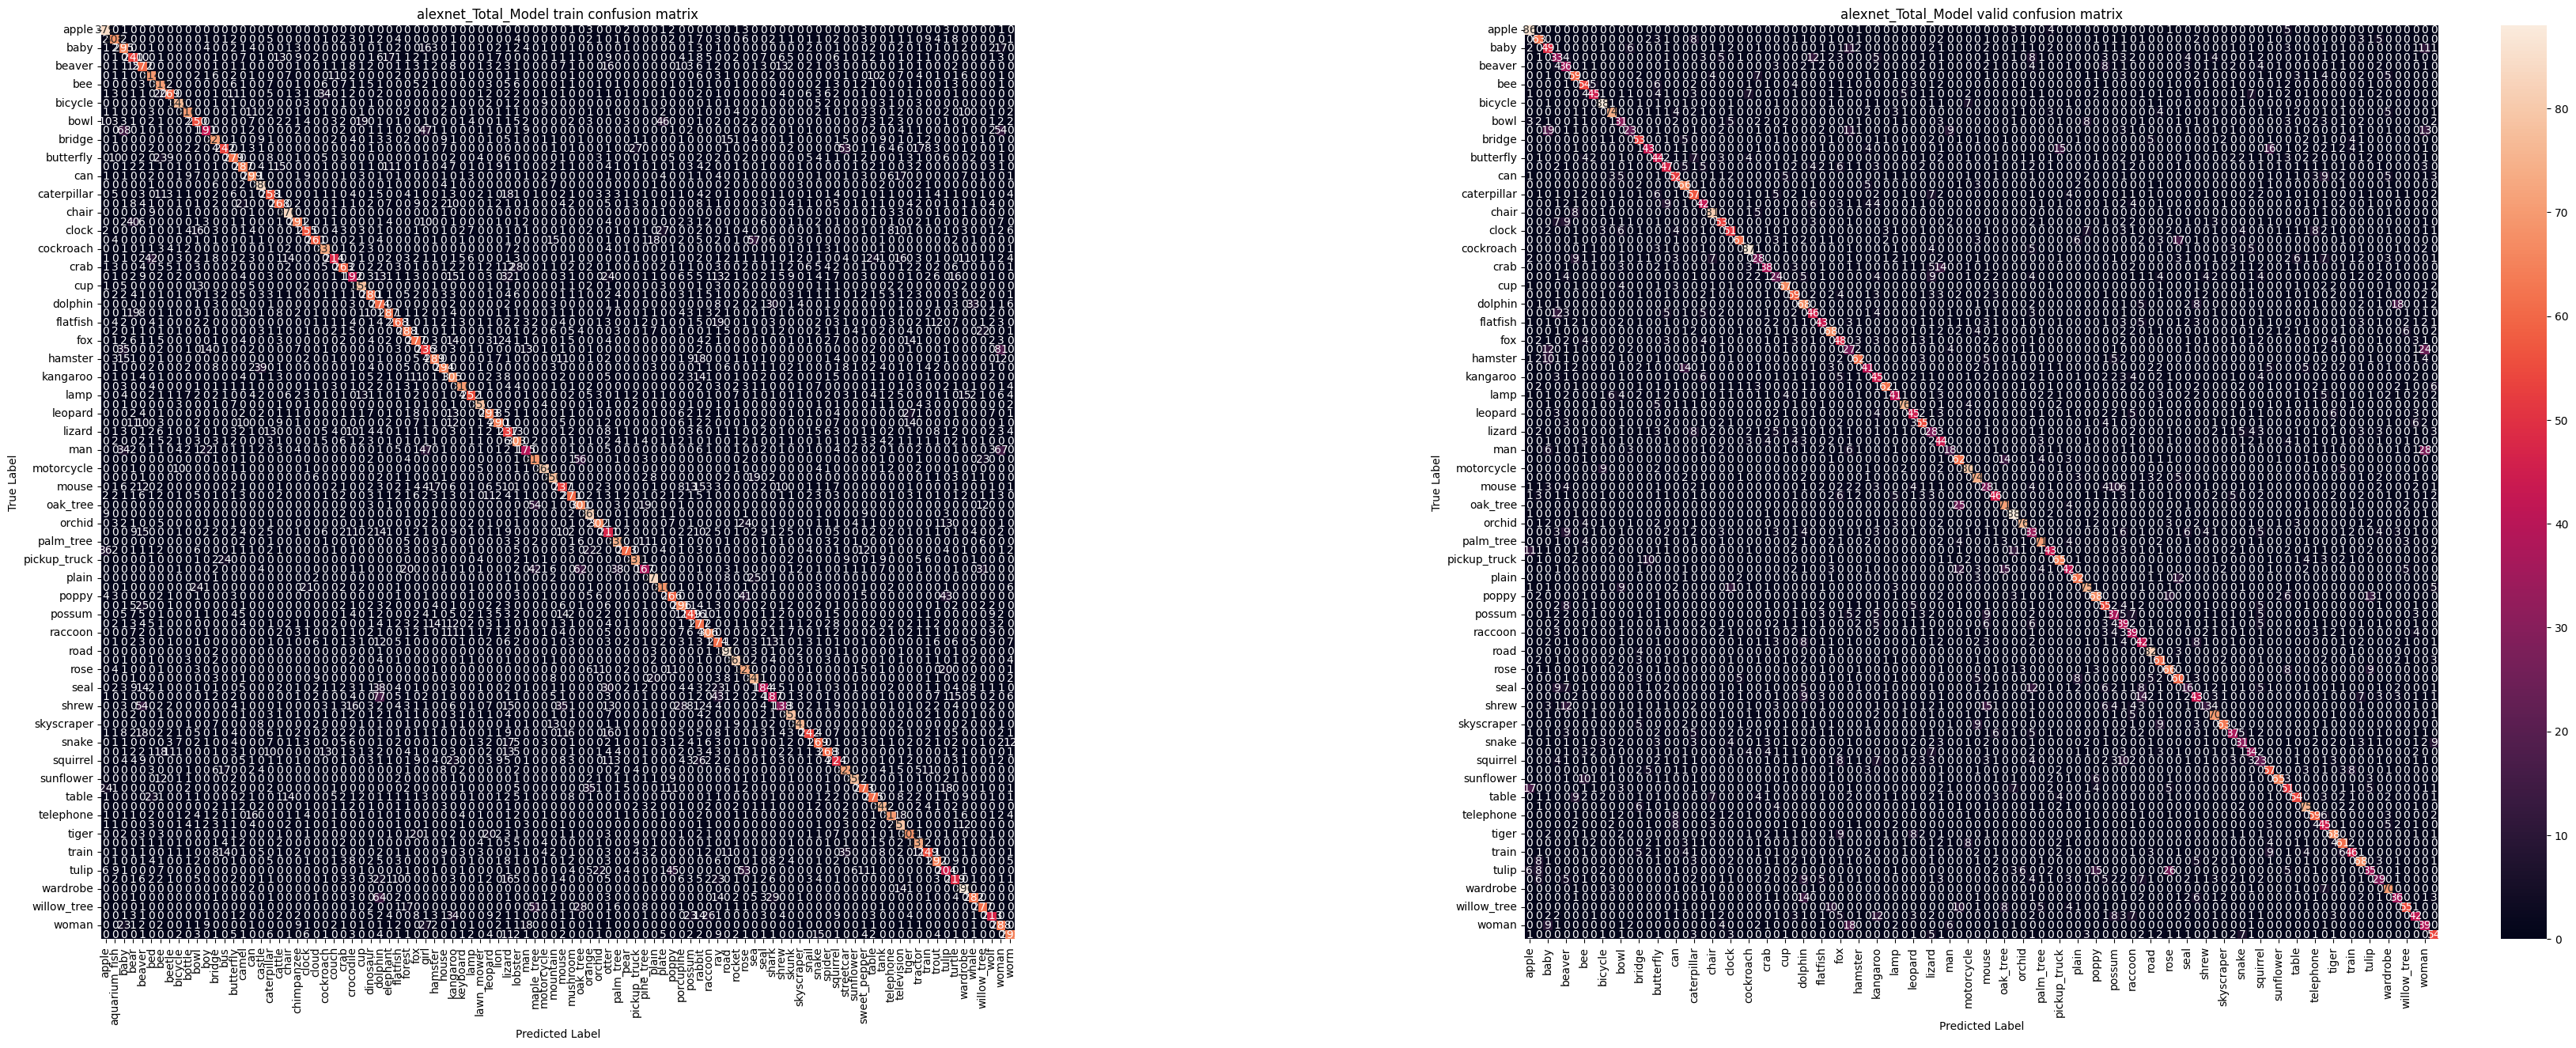

In [43]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

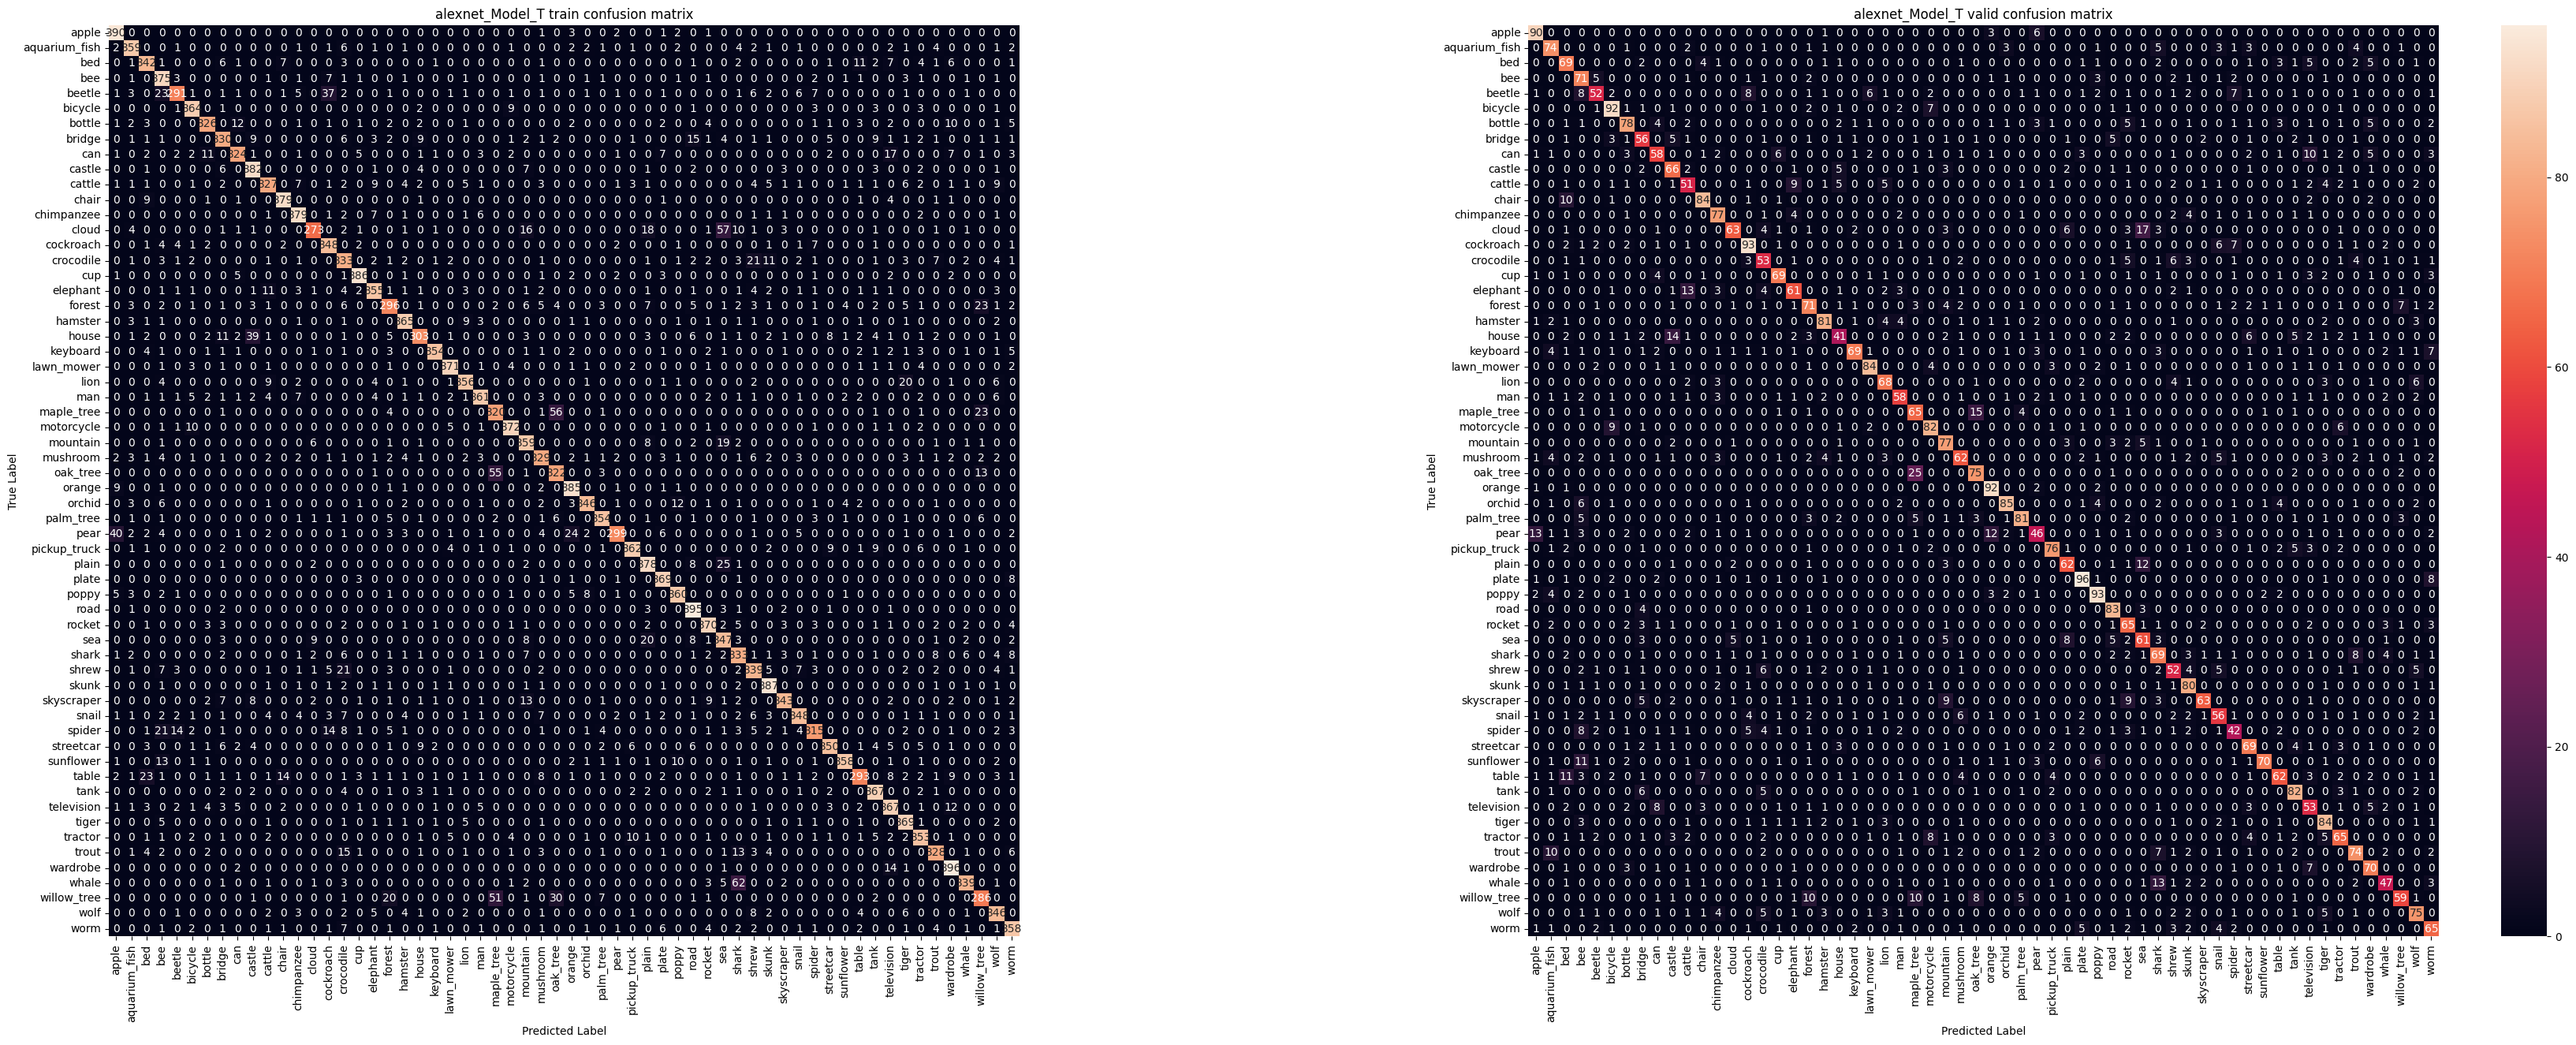

In [44]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

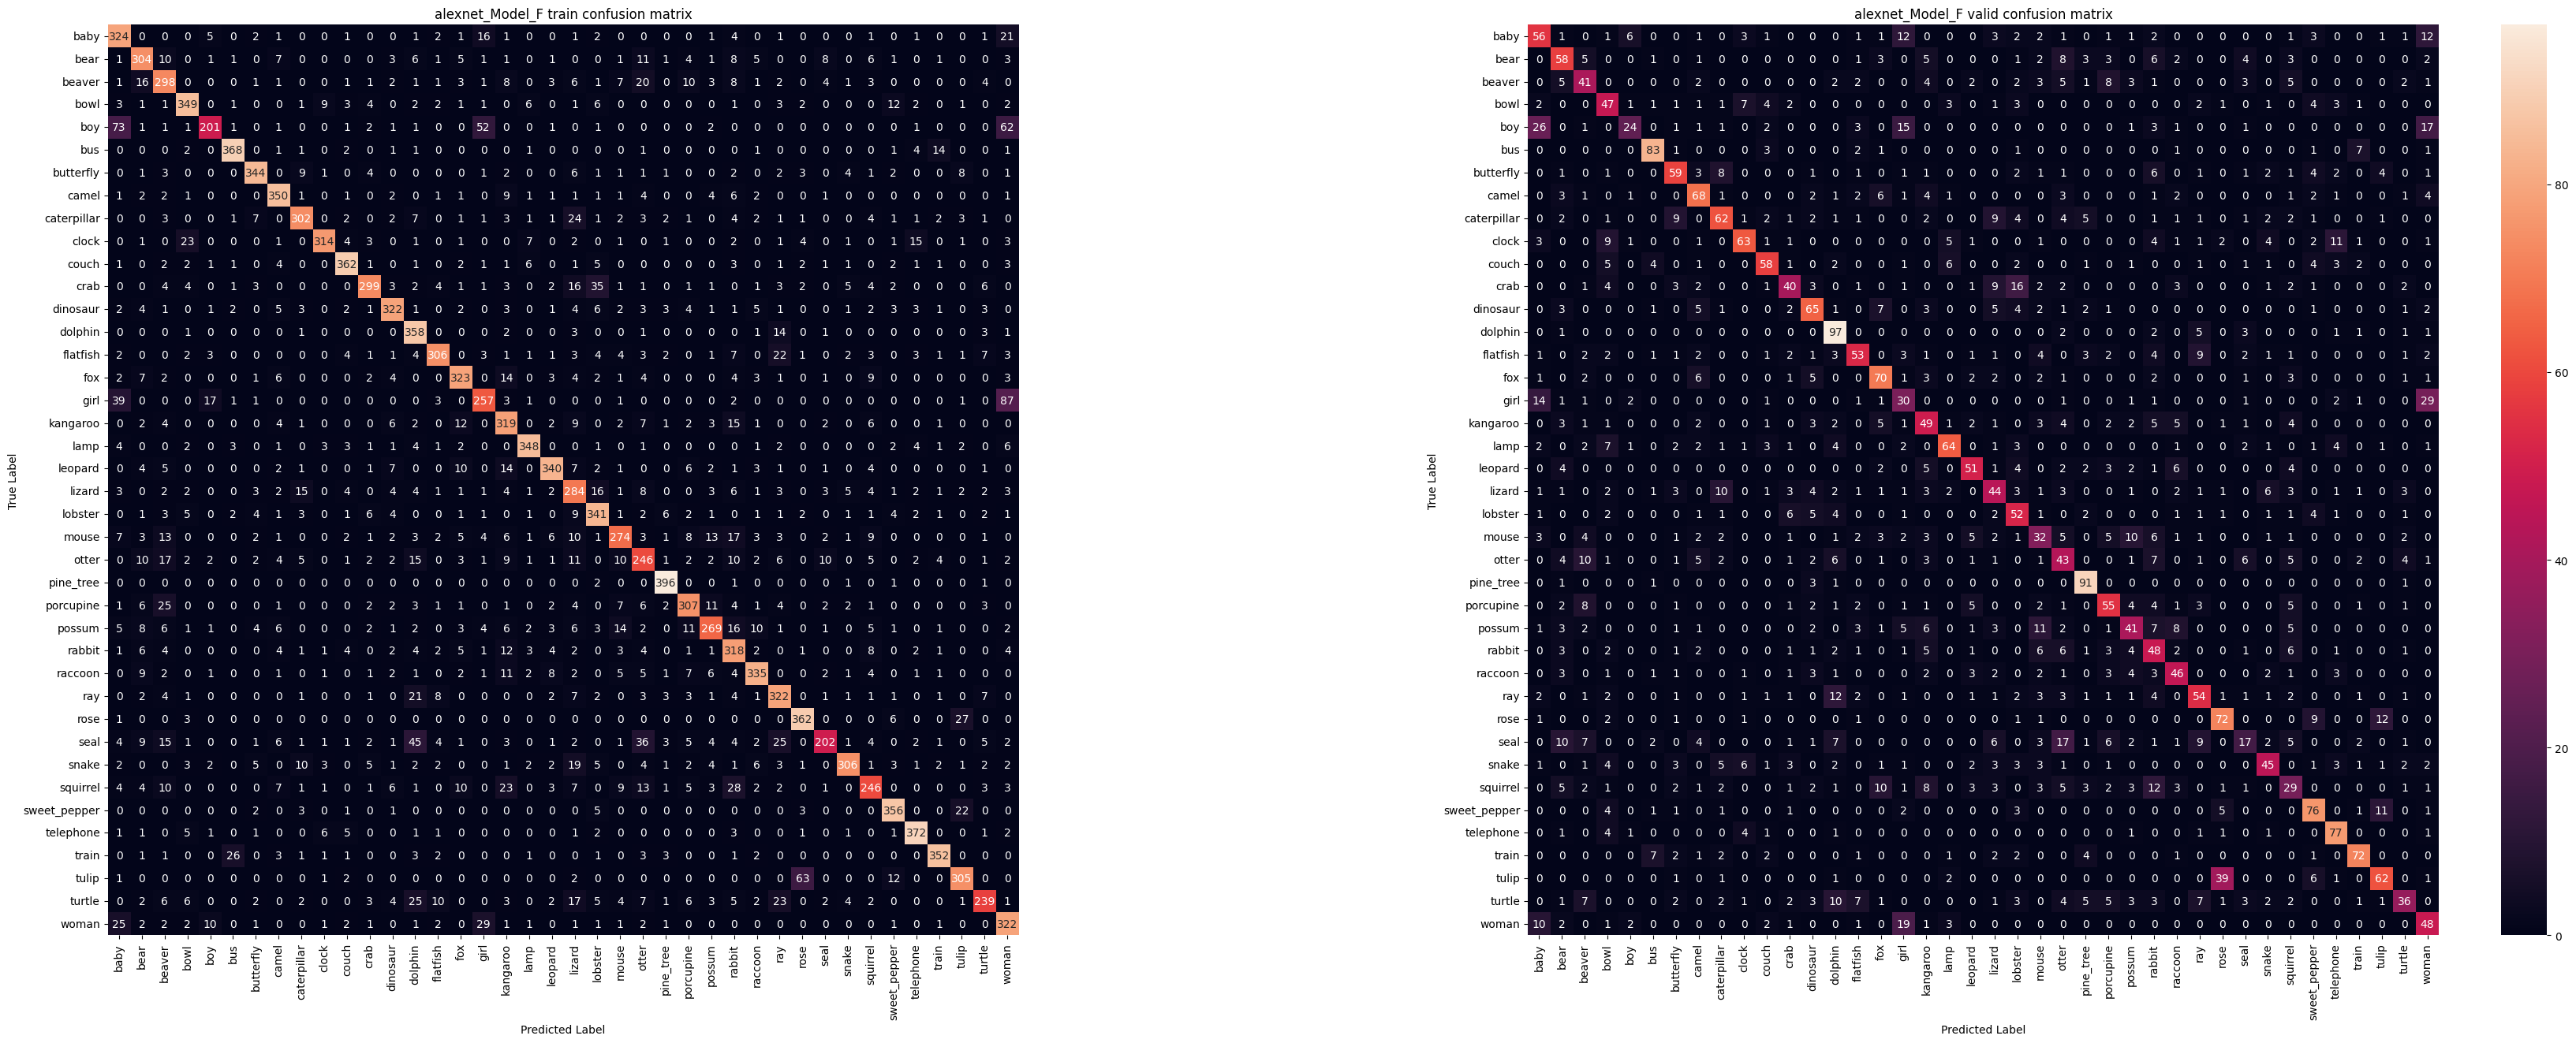

In [45]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [46]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [47]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,12334,21,3,21,21,0.944091,0.999634,0.715153,0.987059,False,True,True,True,True
1,26285,26,26,91,26,0.855486,0.451535,0.323556,0.916694,True,False,True,False,False
2,40762,77,4,77,74,0.369217,0.729133,0.254622,0.846216,False,True,False,True,True
3,29916,13,13,58,58,0.998036,0.986722,0.616750,0.841867,True,False,False,False,False
4,13967,35,35,46,46,0.417226,0.775120,0.149036,0.790290,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,22607,73,30,73,73,0.633374,0.959224,0.687646,0.558256,False,True,True,False,True
39996,42240,31,72,31,31,0.120103,0.564095,0.134512,0.618981,False,True,True,True,True
39997,839,48,26,48,48,0.612605,0.999331,0.885116,0.999312,False,True,True,True,True
39998,28397,15,15,76,31,0.288832,0.222459,0.153197,0.626537,True,False,False,True,False


In [48]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
2,40762,77,4,77,74,0.369217,0.729133,0.254622,0.846216,False,True,False,True,True
3,29916,13,13,58,58,0.998036,0.986722,0.616750,0.841867,True,False,False,False,False
4,13967,35,35,46,46,0.417226,0.775120,0.149036,0.790290,True,False,False,False,False
5,15419,44,44,6,44,0.796440,0.163838,0.111080,0.761464,True,False,True,False,False
6,5910,75,55,75,27,0.316784,0.931620,0.144743,0.594100,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39991,46178,63,63,97,74,0.506635,0.507598,0.165892,0.835584,True,False,False,False,False
39992,40421,85,90,27,27,0.193008,0.290382,0.178623,0.775143,False,False,False,True,True
39995,22607,73,30,73,73,0.633374,0.959224,0.687646,0.558256,False,True,True,False,True
39996,42240,31,72,31,31,0.120103,0.564095,0.134512,0.618981,False,True,True,True,True


In [49]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,10356,35,35,21,35,0.582939,0.612475,0.262517,0.541484,True,False,True,True,False
14,49869,40,40,94,84,0.797047,0.595357,0.433519,0.904495,True,False,False,True,False
29,21928,78,55,27,27,0.282882,0.382763,0.178449,0.733604,False,False,False,True,False
32,16350,11,98,46,46,0.409182,0.744331,0.294692,0.604326,False,False,False,True,False
34,4931,13,25,5,5,0.406824,0.193790,0.236359,0.825910,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39984,48593,85,25,85,85,0.299018,0.989064,0.259996,0.685391,False,True,True,False,True
39990,11231,92,92,6,54,0.727757,0.851759,0.414875,0.532171,True,False,False,True,False
39995,22607,73,30,73,73,0.633374,0.959224,0.687646,0.558256,False,True,True,False,True
39998,28397,15,15,76,31,0.288832,0.222459,0.153197,0.626537,True,False,False,True,False


In [50]:
df_results[(df_results['Decision']==df_results['flag'])&(df_results['Softmax_decision']<0.9)&(df_results['Softmax_F']>df_results['Softmax_T'])&(df_results['Match_F']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
18,26227,58,13,58,58,0.984274,0.953733,0.429958,0.654734,False,True,True,True,True
28,46731,91,30,73,73,0.359263,0.311347,0.176930,0.555154,False,False,False,True,True
62,49737,52,59,52,52,0.999999,0.512497,0.384631,0.759661,False,True,True,True,True
73,442,56,59,56,56,0.995943,0.940660,0.581629,0.851055,False,True,True,True,True
89,12765,79,4,24,24,0.255056,0.221642,0.285396,0.517371,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39940,41089,52,59,52,52,0.991477,0.519595,0.269183,0.845253,False,True,True,True,True
39944,10358,85,90,85,12,0.949387,0.677515,0.156508,0.873432,False,True,False,True,True
39946,47023,52,59,52,52,0.999973,0.652391,0.593624,0.833528,False,True,True,True,True
39969,36374,56,59,56,56,0.974397,0.623618,0.329156,0.833097,False,True,True,True,True


In [51]:
df_results[(df_results['Match_T']!=True)&(df_results['Softmax_T']>0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
3,29916,13,13,58,58,0.998036,0.986722,0.616750,0.841867,True,False,False,False,False
36,18360,35,35,46,46,0.326718,0.967124,0.220318,0.810036,True,False,False,False,False
68,22038,3,3,31,3,0.582349,0.931351,0.395996,0.825027,True,False,True,False,False
75,45392,44,30,95,95,0.455850,0.935255,0.475787,0.533879,False,False,False,False,False
78,29269,30,30,95,95,0.893063,0.944309,0.486016,0.631198,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39931,12670,22,22,61,61,0.855162,0.982778,0.474372,0.532220,True,False,False,False,False
39950,9051,42,42,88,42,0.999792,0.991230,0.536882,0.951785,True,False,True,False,False
39959,1648,35,98,46,46,0.621918,0.999371,0.299201,0.991513,False,False,False,False,False
39973,1557,86,86,20,20,0.588236,0.923442,0.334177,0.522876,True,False,False,True,False


In [52]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

74    233
59    229
46    205
27    183
25    161
     ... 
68      6
17      4
20      4
76      4
60      1
Name: Target, Length: 99, dtype: int64

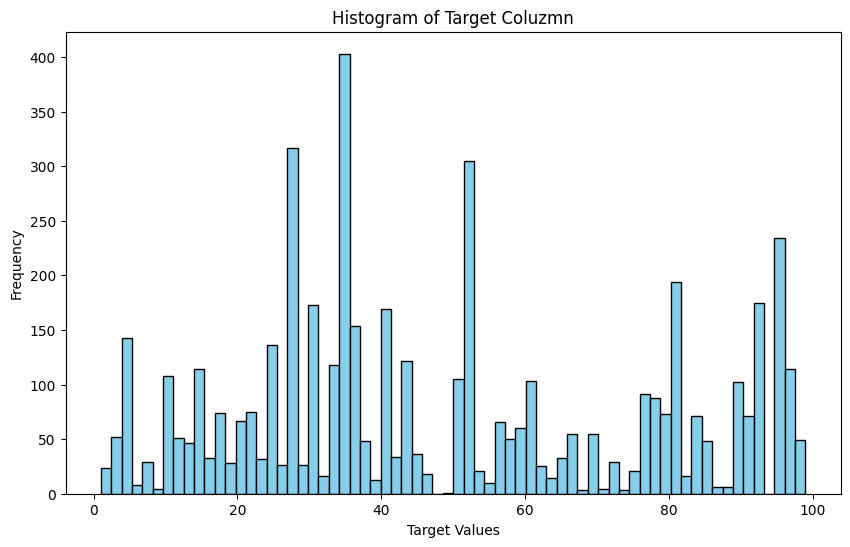

In [ ]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [ ]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,9158,40,40,69,40,0.999260,0.505373,0.596278,0.913356,True,False,True,True,False
1,46299,64,64,36,64,0.996959,0.954952,0.924085,0.980045,True,False,True,False,False
2,14716,57,10,57,57,0.799197,0.992333,0.975296,0.999940,False,True,True,True,True
3,3902,36,50,36,36,0.788974,0.999957,0.964390,0.956619,False,True,True,True,True
4,12378,46,19,75,19,0.557094,0.382502,0.305338,0.529666,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,45651,31,15,31,15,0.255086,0.680685,0.217489,0.795140,False,True,False,False,True
9996,15621,33,92,83,83,0.581079,0.532153,0.231484,0.556051,False,False,False,False,False
9997,39878,29,29,34,29,0.602932,0.473497,0.481780,0.865319,True,False,True,False,False
9998,18933,99,44,99,99,0.955373,0.975073,0.803760,0.925647,False,True,True,True,True


In [ ]:
df_results_v[(df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
4,12378,46,19,75,19,0.557094,0.382502,0.305338,0.529666,False,False,False,False,False
6,6196,32,46,35,98,0.353116,0.924918,0.190123,0.810333,False,False,False,False,False
7,11845,92,92,70,70,0.977920,0.526805,0.341595,0.802308,True,False,False,True,False
9,9630,55,3,21,21,0.840457,0.999822,0.937191,0.557063,False,False,False,False,False
10,11533,40,40,9,40,0.911265,0.326124,0.545703,0.739304,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,16433,10,10,86,10,0.334246,0.342646,0.135655,0.752143,True,False,True,False,False
9993,20669,33,73,69,33,0.328210,0.380929,0.215128,0.610142,False,False,True,False,False
9995,45651,31,15,31,15,0.255086,0.680685,0.217489,0.795140,False,True,False,False,True
9996,15621,33,92,83,83,0.581079,0.532153,0.231484,0.556051,False,False,False,False,False


In [ ]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])&(df_results_v['Decision']==True)&(df_results_v['Match_F']==True)&(df_results_v['Match_T']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,9158,40,40,69,40,0.999260,0.505373,0.596278,0.913356,True,False,True,True,False
7,11845,92,92,70,70,0.977920,0.526805,0.341595,0.802308,True,False,False,True,False
20,3889,10,10,61,61,0.747685,0.966618,0.786901,0.683110,True,False,False,True,False
37,32934,73,73,91,73,0.869681,0.932240,0.501908,0.645590,True,False,True,True,False
74,20536,13,13,81,81,0.707103,0.482017,0.214951,0.545693,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9929,35406,38,38,66,66,0.310345,0.757163,0.314741,0.715981,True,False,False,True,False
9949,19293,37,37,12,37,0.754880,0.404263,0.259335,0.550951,True,False,True,True,False
9958,19840,3,3,21,21,0.693989,0.973573,0.903069,0.852932,True,False,False,True,False
9967,13703,37,37,85,85,0.410702,0.953266,0.788408,0.798452,True,False,False,True,False


In [ ]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

35    84
52    76
92    72
27    62
31    50
      ..
11     4
48     3
60     3
63     3
53     2
Name: Target, Length: 99, dtype: int64

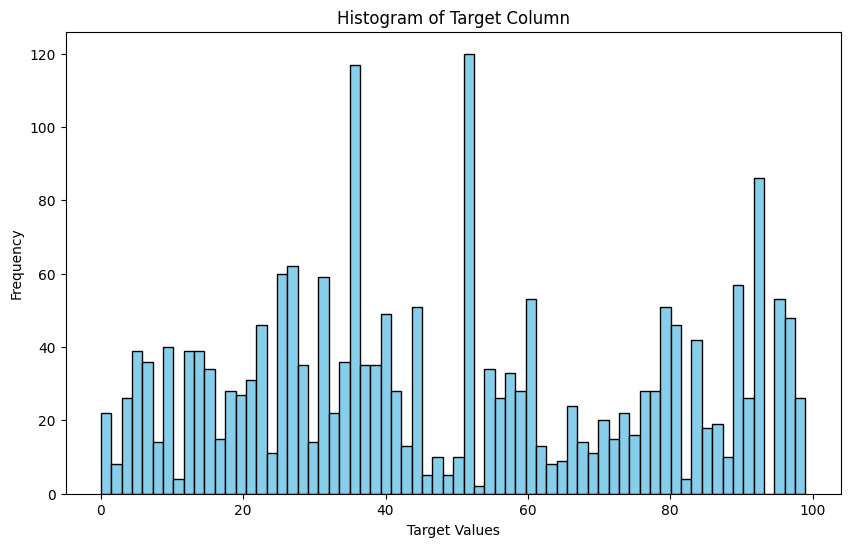

In [ ]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [ ]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_train_loss,total_train_accu,sum_F,sum_T


(11.516211043739318, 0.635125, 12126, 27874)

In [ ]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_valid_loss,total_valid_accu,sum_F,sum_T

(13.88557310180664, 0.4556, 3300, 6700)

In [ ]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            


            for d,t in zip(data,target):
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_d<0.9):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T


In [ ]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_train_loss,total_train_accu,sum_F,sum_T

(6.777555802714825, 0.719275, 12894, 27106)

In [ ]:

total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_valid_loss,total_valid_accu,sum_F,sum_T

(9.514794145965576, 0.5162, 3379, 6621)